<a href="https://colab.research.google.com/github/WMB25/Scientific-Computing-Project/blob/Exercise/EX10/Park_Arquitetura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Arquiteturas:
### FIFO, PRI e SR.

Para está representação os componetes são:
- Frequentadores: Clientes.
- Servidor: Brinquedo (Montanha Russa).

In [137]:
!pip install simpy

In [138]:
import simpy
import random
import statistics
import matplotlib as plt

# Tempo de chegada (taxa de minutos)
FIFO_ARRIVAL_TIME = 3.0 # Comum
PRI_ARRIVE_TIME = 15.0 # Prioridade (VIP)
SR_ARRIVE_TIME = 15.5 # Preferencial

# Parametros da montanha russa (servidor)
QTD_TRAIN = 6
SETS_TRAIN = 4
TOTAL_CAPACITY = QTD_TRAIN * SETS_TRAIN
ENTRY_EXIT_TIME = 4.0
DEVIATION_ENTRY_EXIT = 0.5
JOURNEY_TIME = 2.0
START_LIMITY = 10.0
PLAYTIME = ENTRY_EXIT_TIME + JOURNEY_TIME

# Duração da simulação
SIMULATION_DURATION = 180

WAIT_TIME = []

# Regra da prioridade: A cada dois comuns 1 prioritario.
LAW_FIFO_PRI = 2
# Regra preferencial: A cada três Pessoa (FIFO ou PRI) 1 prioritario.
LAW_SR = 3

## Arquitetura FIFO:

In [139]:
import simpy
import random

# Resource (serviço) -> montanha russa (FIFO)
class Rollercoaster_FIFO:

  def __init__(self, env):
    self.env = env
    self.train = simpy.Resource(env, capacity=1)
    self.boarding_line = []
    self.queue_size_history = []

  def log_queue_sizes(self):
    """Guarda o tamanho atual da fila para metricas/graficos"""
    self.queue_size_history.append((self.env.now, len(self.boarding_line)))

  def cycle_service(self):
    """Calcula o tempo de serviço e simula a duração do passeio."""

    # A 'service_time' é a parte da soma total da variavel de tempo para embarque/desembarque e a fixa de trajetoria
    service_time = (random.normalvariate(ENTRY_EXIT_TIME, DEVIATION_ENTRY_EXIT) + JOURNEY_TIME)
    yield self.env.timeout(max(0, service_time))

  def manage_shipment(self):
    """Lógica de carregamento do trem em lote (FIFO)."""
    while True:
      self.log_queue_sizes()
      with self.train.request() as req:
        yield req

        wait_start = self.env.now
        while len(self.boarding_line) < TOTAL_CAPACITY and (self.env.now - wait_start) < START_LIMITY:
          yield self.env.timeout(1)
          self.log_queue_sizes()

        crew_of_gear = []
        num_crew = min(len(self.boarding_line), TOTAL_CAPACITY)

        for _ in range(num_crew):
          gear = self.boarding_line.pop(0)
          wait_time = self.env.now - gear['arrive_time']
          WAIT_TIME.append(wait_time)
          crew_of_gear.append(gear['id'])

        if not crew_of_gear:
          yield self.env.timeout(1)
          self.log_queue_sizes()
          continue

        # Inicia o brinquedo
        yield self.env.process(self.cycle_service())
        self.log_queue_sizes()

## Arquitetura FIFO e PRI:

In [140]:
# Resource (serviço) -> montanha russa (FIFO e PR0)
class Rollercoaster_FIFO_PRI:

  def __init__(self, env):
    self.env = env
    self.train = simpy.Resource(env, capacity=1)
    self.commom_line = []
    self.priority_line = []

    self.wait_queue = { 'Comum': [], 'Prioridade': [] }
    self.time_in_system = { 'Comum': [], 'Prioridade': [] }

    # Controle da regra
    self.counter_fifo = 0
    self.queue_size_history = []

  def log_queue_sizes(self):
    """Guarda o tamanho atual das filas para metricas/graficos"""
    self.queue_size_history.append((self.env.now, len(self.commom_line), len(self.priority_line)))

  def cycle_service(self, goers):
    """Simula o tempo que o trem leva com o grupo (FIFO+PRI)."""
    service_time = random.normalvariate(ENTRY_EXIT_TIME, DEVIATION_ENTRY_EXIT) + JOURNEY_TIME
    yield self.env.timeout(service_time)

    # Tempo
    for goer in goers:
      total_time = self.env.now - goer['arrival_time']
      self.time_in_system[goer['type']].append(total_time)

  def menage_shipiment(self):
    """Lógica de gerenciamento das duas filas e prioridade"""
    while True:
      self.log_queue_sizes()
      if not (self.commom_line or self.priority_line):
        yield self.env.timeout(1)
        continue

      boarding_group = []

      with self.train.request() as req:
        yield req

        while len(boarding_group) < TOTAL_CAPACITY and (self.commom_line or self.priority_line):
          next_goer = None

          # Regra de prioridade (VIP depois de 2 clientes comuns)
          if self.priority_line and (self.counter_fifo >= LAW_FIFO_PRI or not self.commom_line):
            next_goer = self.priority_line.pop(0)
            self.counter_fifo = 0
          elif self.commom_line:
            next_goer = self.commom_line.pop(0)
            self.counter_fifo += 1

          if next_goer is None:
            break

          # Tempo na fila
          wait_queue = self.env.now - next_goer['arrival_time']
          self.wait_queue[next_goer['type']].append(wait_queue)

          boarding_group.append(next_goer)

        # se ninguém embarcou, não roda trem vazio
        if not boarding_group:
          yield self.env.timeout(1)
          self.log_queue_sizes()
          continue

        yield self.env.process(self.cycle_service(boarding_group))
        self.log_queue_sizes()

## Arquitetura FIFO, PRI e SR:

In [141]:
# Resource (serviço) -> montanha russa (FIFO, PR0 e SR)
class Rollercoaster_FIFO_PRI_SR:
  def __init__(self, env):
    self.env = env

    self.train = simpy.Resource(env, capacity=1)

    self.commom_line = []
    self.priority_line = []
    self.special_line = []

    self.counter_commom_line = 0
    self.counter_total_served = 0

    self.wait_queue = {'Comum': [], 'Prioridade': [], 'Preferencial' : []}
    self.time_in_system = {'Comum': [], 'Prioridade': [], 'Preferencial' : []}

    self.queue_size_history = []

  def log_queue_sizes(self):
    """Gurda o tamanho atual das filas para metricas/graficos"""
    self.queue_size_history.append(
        (self.env.now, len(self.commom_line), len(self.priority_line), len(self.special_line))
    )

  def cycle_service(self, group):
    """Lista de passageiros embarcados"""
    service_time = random.normalvariate(ENTRY_EXIT_TIME, DEVIATION_ENTRY_EXIT) + JOURNEY_TIME
    yield self.env.timeout(max(0, service_time))

    for goer in group:
      time_in_system = self.env.now - goer['arrival_time']
      self.time_in_system[goer['type']].append(time_in_system)

  def choose_next_passenger(self):
    """Escolhe um passageiro respeintando as regras"""

    # 1) Regra preferencial
    if self.special_line and (self.counter_total_served >= LAW_SR):
      goer = self.special_line.pop(0)
      self.counter_total_served = 0
      return goer

    # 2) Regra prioridade
    if self.priority_line and (self.counter_commom_line >= LAW_FIFO_PRI or not self.commom_line):
      goer = self.priority_line.pop(0)
      self.counter_commom_line = 0
      self.counter_total_served += 1
      return goer

    # 3) Comum
    if self.commom_line:
      goer = self.commom_line.pop(0)
      self.counter_commom_line += 1
      self.counter_total_served += 1
      return goer

    return None

  def manager_shipment(self):
    """gerenciamento da filas."""
    while True:
      if not (self.commom_line or self.priority_line or self.special_line):
        self.log_queue_sizes()
        yield self.env.timeout(1)
        continue

      with self.train.request() as req:
        yield req
        boarding_group = []
        wait_start = self.env.now

        while len(boarding_group) < TOTAL_CAPACITY and (self.commom_line or self.priority_line or self.special_line):
          passenger = self.choose_next_passenger()
          if passenger is None:
            break

          wait_time = self.env.now - passenger['queue_entry_time']
          self.wait_queue[passenger['type']].append(wait_time)

          boarding_group.append(passenger)


      self.log_queue_sizes()

      if not boarding_group:
        yield self.env.timeout(1)
        continue

      yield self.env.process(self.cycle_service(boarding_group))

### SIstemas de Chegada dos clientes:

In [146]:
import random

# FIFO
def arrive_gears_FIFO(env, rollercoaster):
  gear_id = 0

  while True:
    wait_time = random.expovariate(1.0 / FIFO_ARRIVAL_TIME)
    yield env.timeout(wait_time)

    gear_id += 1
    customer = {
        'id' : gear_id,
        'arrive_time' : env.now
    }
    rollercoaster.boarding_line.append(customer)
    rollercoaster.log_queue_sizes()


# FIFO e PRI
def arrive_gears_FIFO_PRI(env, rollercoaster):
  """Gera os clinetes e os coloca nas filas"""
  gear_id = 0

  while True:
    # Comuns
    commom_wait_time = random.expovariate(1.0 / FIFO_ARRIVAL_TIME)
    yield env.timeout(commom_wait_time)
    gear_id += 1

    customer_commom = {
        'id' : gear_id,
        'type' : 'Comum',
        'arrival_time' : env.now,
        'queue_entry_time': env.now
    }
    rollercoaster.commom_line.append(customer_commom)
    rollercoaster.log_queue_sizes()

    # VIP (Prioridade)
    if random.random() < (FIFO_ARRIVAL_TIME / PRI_ARRIVE_TIME):
      gear_id += 1
      customer_priority = {
          'id' : gear_id,
          'type' : 'Prioridade',
          'arrival_time' : env.now,
          'queue_entry_time' : env.now
      }
      rollercoaster.priority_line.append(customer_priority)
      rollercoaster.log_queue_sizes()


def arrive_gears_FIFO_PRI_SR(env, rollercoaster):
  current_id = 0

  while True:
    commom_wait_time = random.expovariate(1.0/FIFO_ARRIVAL_TIME)
    yield env.timeout(commom_wait_time)
    current_id += 1

    customer_commom = {
        'id': current_id,
        'type': 'Comum',
        'arrival_time': env.now,
        'queue_entry_time': env.now
    }
    rollercoaster.commom_line.append(customer_commom)
    rollercoaster.log_queue_sizes() # Adicionado para registrar a chegada do comum

    # Probabilidade de chegar um VIP
    if random.random() < (FIFO_ARRIVAL_TIME / PRI_ARRIVE_TIME):
        current_id += 1
        customer_priority = {
            'id': current_id,
            'type': 'Prioridade',
            'arrival_time': env.now,
            'queue_entry_time': env.now
        }
        rollercoaster.priority_line.append(customer_priority)
        rollercoaster.log_queue_sizes() # Adicionado para registrar a chegada do prioritário

    # Probabilidade de chegar preferencial
    if random.random() < (FIFO_ARRIVAL_TIME / SR_ARRIVE_TIME):
        current_id += 1
        customer_special = {
            'id': current_id,
            'type': 'Preferencial',
            'arrival_time': env.now,
            'queue_entry_time': env.now
        }
        rollercoaster.special_line.append(customer_special)
        rollercoaster.log_queue_sizes() # Adicionado para registrar a chegada do preferencial

### Metricas:

In [147]:
import matplotlib.pyplot as plt
import statistics

# FIFO, PRI e SR
def plot_metrics(rollercoaster):
    # Tempo médio na fila
    types = ['Comum', 'Prioridade', 'Preferencial']
    avg_queue = []
    avg_system = []

    for t in types:
        avg_queue.append(statistics.mean(rollercoaster.wait_queue[t]) if rollercoaster.wait_queue[t] else 0)
        avg_system.append(statistics.mean(rollercoaster.time_in_system[t]) if rollercoaster.time_in_system[t] else 0)

    # 1) Tempo na fila x tipo
    plt.figure()
    plt.bar(types, avg_queue)
    plt.title("Tempo médio na FILA por tipo")
    plt.xlabel("Tipo")
    plt.ylabel("Tempo (min)")
    plt.show()

    print("\n")


    # 2) Tempo no SISTEMA por tipo
    plt.figure()
    plt.bar(types, avg_system)
    plt.title("Tempo médio no SISTEMA por tipo")
    plt.xlabel("Tipo")
    plt.ylabel("Tempo (min)")
    plt.show()

    print("\n")

    # 3) Evolução do tamanho das filas
    if rollercoaster.queue_size_history:
        times, fifo_sizes, pri_sizes, pref_sizes = zip(*rollercoaster.queue_size_history)

        plt.figure()
        plt.plot(times, fifo_sizes, label="Comum")
        plt.plot(times, pri_sizes, label="Prioridade")
        plt.plot(times, pref_sizes, label="Preferencial")
        plt.title("Tamanho das filas ao longo do tempo")
        plt.xlabel("Tempo (min)")
        plt.ylabel("Tamanho da fila")
        plt.legend()
        plt.show()


def plot_metrics_fifo_pri(rollercoaster):
    types = ['Comum', 'Prioridade']
    avg_queue = []
    avg_system = []

    for t in types:
        avg_queue.append(statistics.mean(rollercoaster.wait_queue[t]) if rollercoaster.wait_queue[t] else 0)
        avg_system.append(statistics.mean(rollercoaster.time_in_system[t]) if rollercoaster.time_in_system[t] else 0)

    # Fila
    plt.figure()
    plt.bar(types, avg_queue)
    plt.title("FIFO+PRI - Tempo médio na FILA")
    plt.xlabel("Tipo")
    plt.ylabel("Tempo (min)")
    plt.show()

    print("\n")

    # Sistema
    plt.figure()
    plt.bar(types, avg_system)
    plt.title("FIFO+PRI - Tempo médio no SISTEMA")
    plt.xlabel("Tipo")
    plt.ylabel("Tempo (min)")
    plt.show()

    print("\n")

    # 3) Evolução do tamanho das filas (FIFO e PRI)
    if rollercoaster.queue_size_history:
        times, commom_sizes, priority_sizes = zip(*rollercoaster.queue_size_history)

        plt.figure()
        plt.plot(times, commom_sizes, label="Comum")
        plt.plot(times, priority_sizes, label="Prioridade")
        plt.title("Tamanho das filas (FIFO+PRI) ao longo do tempo")
        plt.xlabel("Tempo (min)")
        plt.ylabel("Tamanho da fila")
        plt.legend()
        plt.show()

def plot_metrics_fifo(rollercoaster):
    if not WAIT_TIME:
        print("Sem dados para FIFO.")
        return

    avg_wait = statistics.mean(WAIT_TIME)
    plt.figure()
    plt.bar(['FIFO'], [avg_wait])
    plt.title("FIFO - Tempo médio na FILA")
    plt.ylabel("Tempo (min)")
    plt.show()

    print("\n")

    # Evolução do tamanho da fila (FIFO)
    if rollercoaster.queue_size_history:
        times, fifo_sizes = zip(*rollercoaster.queue_size_history)

        plt.figure()
        plt.plot(times, fifo_sizes, label="Fila Única")
        plt.title("Tamanho da fila (FIFO) ao longo do tempo")
        plt.xlabel("Tempo (min)")
        plt.ylabel("Tamanho da fila")
        plt.legend()
        plt.show()

#### Testes Das Filas:

In [154]:
def test_fifo():
  env = simpy.Environment()
  rollercoaster = Rollercoaster_FIFO(env)

  env.process(arrive_gears_FIFO(env, rollercoaster))
  env.process(rollercoaster.manage_shipment())

  env.run(until=SIMULATION_DURATION)

  plot_metrics_fifo(rollercoaster)

  if WAIT_TIME:
    average_waiting_time = statistics.mean(WAIT_TIME)
    waiting_max = max(WAIT_TIME)
    print(f"Total de frequentadores atendidos: {len(WAIT_TIME)}")
    print(f"Tempo médio de espera Unica: {average_waiting_time:.2f} minutos")
    print(f"Tempo maximo de espera: {waiting_max:.2f} minutos")
    print(f"Tamanho final da fila: {len(rollercoaster.boarding_line)}")
  else:
    print("Nenhum frequentador foi atendida durante a simulação.")


def test_fifo_pri():
  env = simpy.Environment()
  rollercoaster = Rollercoaster_FIFO_PRI(env)

  env.process(arrive_gears_FIFO_PRI(env, rollercoaster))
  env.process(rollercoaster.menage_shipiment())

  env.run(until=SIMULATION_DURATION)

  plot_metrics_fifo_pri(rollercoaster)

  if rollercoaster.wait_queue['Comum']:
    avarage_time_commom = statistics.mean(rollercoaster.wait_queue['Comum'])
    print(f"Tempo médio de espera para comuns: {avarage_time_commom:.2f} min")
  else:
     print("Nenhum cliente comum atendido!")

  if rollercoaster.wait_queue['Prioridade']:
    avarage_time_priority = statistics.mean(rollercoaster.wait_queue['Prioridade'])
    print(f"Tempo médio de espera para prioritario (VIP): {avarage_time_priority:.2f} min")
  else:
    print("Nenhum cliente prioritario (VIP) atendido!")

  print(f"total de clientes comum atendidos: {len(rollercoaster.wait_queue['Comum'])}")
  print(f"total de clientes prioridade (VIP) atendidos: {len(rollercoaster.wait_queue['Prioridade'])}")


def test_fifo_pri_sr():
    env = simpy.Environment()
    rollercoaster = Rollercoaster_FIFO_PRI_SR(env)

    env.process(arrive_gears_FIFO_PRI_SR(env, rollercoaster))
    env.process(rollercoaster.manager_shipment())

    env.run(until=SIMULATION_DURATION)

    plot_metrics(rollercoaster)

    for t in ['Comum', 'Prioridade', 'Preferencial']:
        if rollercoaster.wait_queue[t]:
            avg_q = statistics.mean(rollercoaster.wait_queue[t])
            print(f"Tempo médio na FILA ({t}): {avg_q:.2f} min")
        else:
            print(f"Nenhum {t} foi atendido (fila).")

    for t in ['Comum', 'Prioridade', 'Preferencial']:
        if rollercoaster.time_in_system[t]:
            avg_sys = statistics.mean(rollercoaster.time_in_system[t])
            print(f"Tempo médio no SISTEMA ({t}): {avg_sys:.2f} min")
        else:
            print(f"Nenhum {t} teve tempo de sistema calculado.")

    if rollercoaster.queue_size_history:
        times, fifo_sizes, pri_sizes, pref_sizes = zip(*rollercoaster.queue_size_history)
        print(f"Tamanho médio fila comum: {statistics.mean(fifo_sizes):.2f}")
        print(f"Tamanho médio fila prioridade: {statistics.mean(pri_sizes):.2f}")
        print(f"Tamanho médio fila preferencial: {statistics.mean(pref_sizes):.2f}")


FIFO TESTE


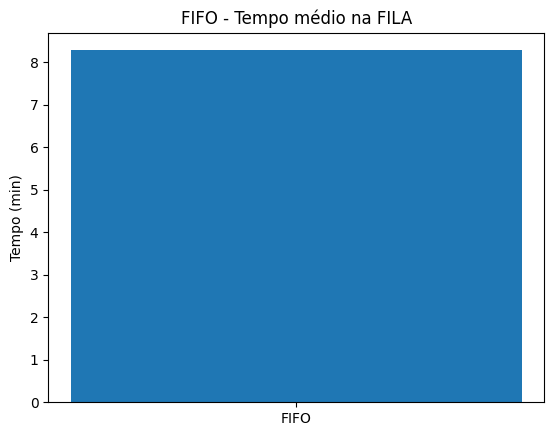

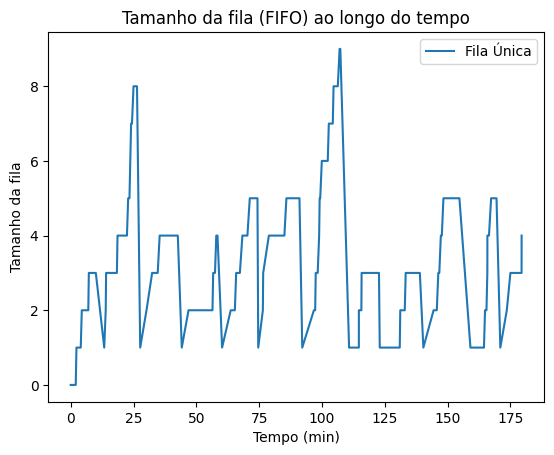

Total de frequentadores atendidos: 279
Tempo médio de espera Unica: 8.28 minutos
Tempo maximo de espera: 16.54 minutos
Tamanho final da fila: 4

 FIFO-PRI TETSE


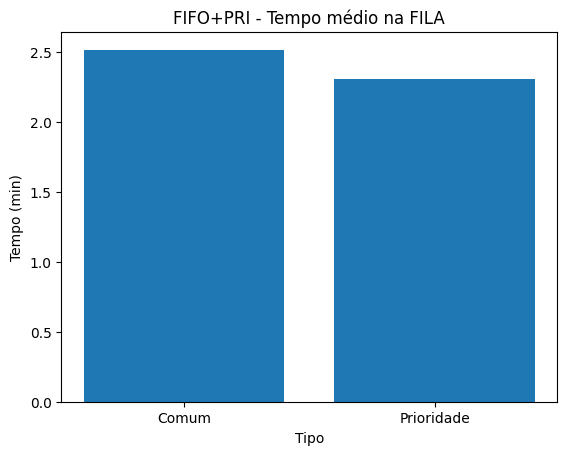

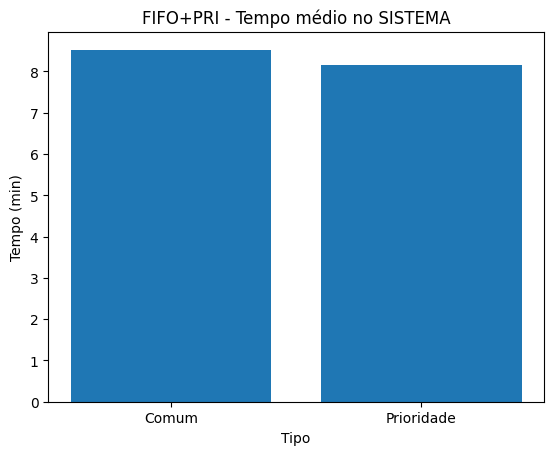

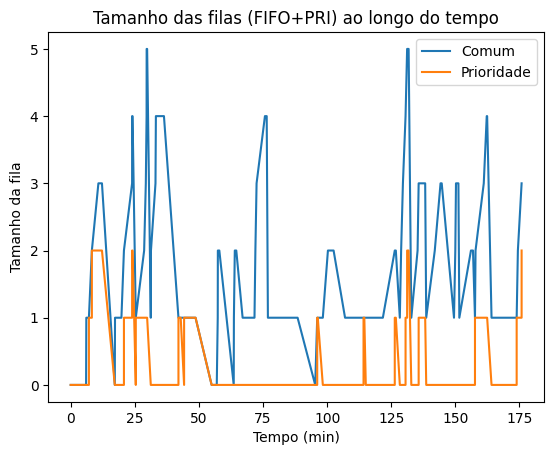

Tempo médio de espera para comuns: 2.52 min
Tempo médio de espera para prioritario (VIP): 2.31 min
total de clientes comum atendidos: 61
total de clientes prioridade (VIP) atendidos: 14

 SR TESTE


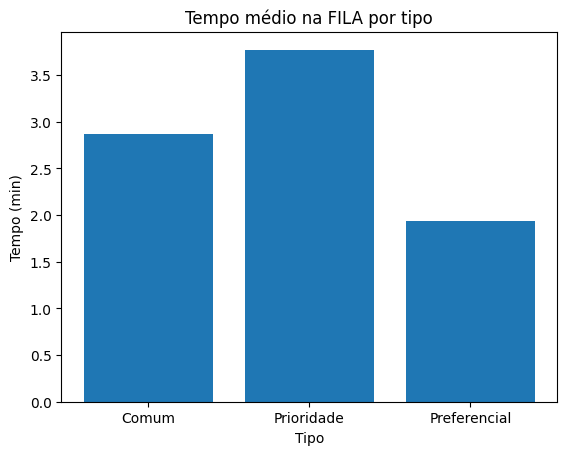

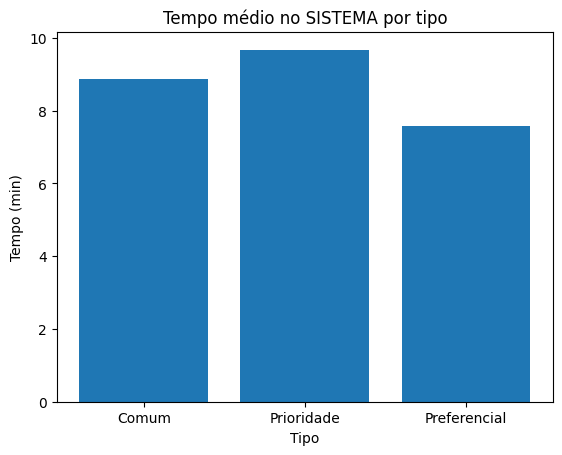

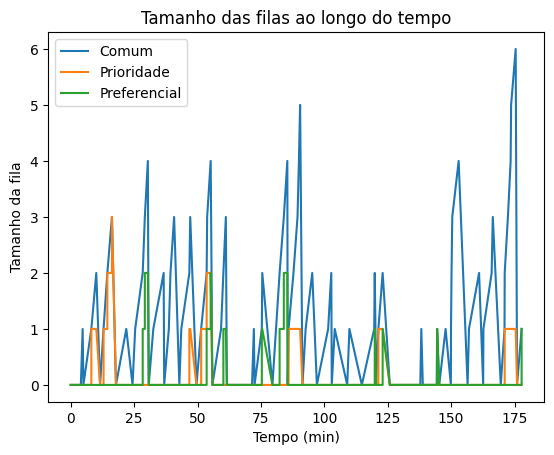

Tempo médio na FILA (Comum): 2.87 min
Tempo médio na FILA (Prioridade): 3.77 min
Tempo médio na FILA (Preferencial): 1.94 min
Tempo médio no SISTEMA (Comum): 8.88 min
Tempo médio no SISTEMA (Prioridade): 9.67 min
Tempo médio no SISTEMA (Preferencial): 7.59 min
Tamanho médio fila comum: 1.33
Tamanho médio fila prioridade: 0.28
Tamanho médio fila preferencial: 0.19


In [155]:
def main():
  print("FIFO TESTE")
  test_fifo()
  print("\n FIFO-PRI TETSE")
  test_fifo_pri()
  print("\n SR TESTE")
  test_fifo_pri_sr()

if __name__ == "__main__":
  main()